# Homework 3 (you need to complete this homework or HW2).

Source with comments : http://blog.ethanrosenthal.com/2016/01/09/explicit-matrix-factorization-sgd-als/

1. Compare recommendations quality (MAE, RMSE, HitRate etc.) and inference time for ALS (Alternating Least Squares without biases) and SGD (Stochastic Gradient Descent without biases) using different regularization values (0.001, 0.01, ...) and factors (1, 10, 25, 50, ...). Improve the code to implement SGD.

2. Change the ALS code so it can perform calculations with biases. Decent instructions can be found here: http://activisiongamescience.github.io/2016/01/11/Implicit-Recommender-Systems-Biased-Matrix-Factorization/.

3. Compare all 4 approaches by MAE, RMSE, training time, and inference time. Put your results (in addition to ipython cells runs) in a summary table. Make qualitative conclusions.

4. Make your own explanation why this ALS implementation does not work good w.r.t. MSE. Try to enhance it if possible or compare it with other implementation(s) (e.g., ALS from Apache Spark MLlib).

**Data source:** suggested 33M, 20M, 10M or 1M ratings among MovieLens datasets (https://grouplens.org/datasets/movielens/) depending on the capacity of your machine (please print your system info in the first notebook cells), basic – MovieLens 100k. You can choose another dataset, but it cannot have smaller number of ratings or users and items than MovieLens 100k.

Send your reports to _dmitrii.ignatov@gmail.com_ with obligatory CC to TAs Alashaui Rafif (_Alshaui.R@hse.ru_), Denis Pozdnyakov (_dvpozdnyakov@hse.ru_), and Roman Naumkin (_rinaumkin@edu.hse.ru_). Topic:  [RecSys2025-HW3]-< LastName_FirstName >.

**Soft Deadline:** 14.12.2025

**Hard Deadline:** 16.12.2025


The model loss function:

$L = \sum\limits_{u,i}(r_{ui} - (\mu + b_{u} + b_{i} + \textbf{x}_{u}^{\intercal} \cdot{} \textbf{y}_{i}))^{2}$+$\lambda_{xb} \sum\limits_{u} \left\Vert b_{u} \right\Vert^{2} + \lambda_{yb}\sum\limits_{i} \left\Vert b_{i} \right\Vert^{2}+
\lambda_{xf} \sum\limits_{u} \left\Vert \textbf{x}_{u} \right\Vert^{2} + \lambda_{yf} \sum\limits_{i} \left\Vert \textbf{y}_{i} \right\Vert^{2}$

In [1]:
%load_ext jupyter_black

In [2]:
import numpy as np
import pandas as pd

from os import getcwd
from os.path import join
from tqdm.notebook import tqdm, trange

np.random.seed(0)

My system info:

In [3]:
!screenfetch

                   -`                 
                  .o+`                 jilezka@clanka
                 `ooo/                 OS: Arch Linux 
                `+oooo:                Kernel: x86_64 Linux 6.17.9-arch1-1
               `+oooooo:               Uptime: 4h 42m
               -+oooooo+:              Packages: 941
             `/:-:++oooo+:             Shell: python3.11
            `/++++/+++++++:            Resolution: No X Server
           `/++++++++++++++:           WM: Hyprland :D
          `/+++ooooooooooooo/`         GTK Theme: Adwaita [GTK2/3]
         ./ooosssso++osssssso+`        Icon Theme: Adwaita
        .oossssso-````/ossssss+`       Font: Adwaita Sans 11
       -osssssso.      :ssssssso.      Disk: 569G / 3.7T (16%)
      :osssssss/        osssso+++.     CPU: AMD Ryzen 7 8700F 8-Core @ 16x 5.05532GHz
     /ossssssss/        +ssssooo/-     GPU: NVIDIA GeForce RTX 5080
   `/ossssso+/:-        -:/+osssso+-   RAM: 3361MiB / 31642MiB
  `+sso+:-`                 

## Load data and create ratings matrix $r_{ij}$

In this work I will use Movielens-1M dataset (I tried 10M, but total inference time whould have been around five and a half hours).

In [4]:
# Define file paths (adjust the path to your extracted files)
data_folder = join(getcwd(), "data", "ml-1m")
ratings_file = join(data_folder, "ratings.dat")

df_ratings = pd.read_table(
    ratings_file,
    sep="::",
    header=None,
    names=["user_id", "item_id", "rating", "timestamp"],
    engine="python",
)

In [5]:
df_ratings.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
users = df_ratings.user_id.unique()
items = df_ratings.item_id.unique()

user_index = {item: i for i, item in enumerate(users)}
item_index = {item: i for i, item in enumerate(items)}

# Create r_{ui}, our ratings matrix
ratings = np.zeros((len(users), len(items)))
for _, usr, item, rating, _ in df_ratings.itertuples():
    ratings[user_index[usr], item_index[item]] = rating

ratings

array([[5., 3., 3., ..., 0., 0., 0.],
       [5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 3., 4., ..., 0., 0., 0.],
       [4., 0., 0., ..., 0., 0., 0.]])

In [7]:
del users, items, user_index, item_index

## Split test and train

In [8]:
# Split into training and test sets.
# Remove 10 ratings for each user and assign them to the test set
def train_test_split(ratings):
    test = np.zeros(ratings.shape)
    train = ratings.copy()
    for user in trange(len(ratings), desc="Generating train & test splits"):
        test_ratings = np.random.choice(
            ratings[user, :].nonzero()[0], size=10, replace=False
        )
        train[user, test_ratings] = 0.0
        test[user, test_ratings] = ratings[user, test_ratings]

    # Test and training are truly disjoint
    assert np.all((train * test) == 0)
    return train, test

In [9]:
train, test = train_test_split(ratings)
del ratings

Generating train & test splits:   0%|          | 0/6040 [00:00<?, ?it/s]

## Metric

In [10]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error


def get_mse(y_pred, y_true):
    mask = y_true.nonzero()
    pred = y_pred[mask].flatten()
    true = y_true[mask].flatten()
    return mean_squared_error(pred, true)


def get_rmse(y_pred, y_true):
    mask = y_true.nonzero()
    pred = y_pred[mask].flatten()
    true = y_true[mask].flatten()
    return root_mean_squared_error(pred, true)

## Class implementing ALS and ExplicitMF with gradient descent and biases

In [12]:
from time import time
from numpy.linalg import solve


class ExplicitMF:
    def __init__(
        self,
        ratings,
        n_factors=40,
        optim="sgd",
        bias=True,
        item_fact_reg=0.0,
        user_fact_reg=0.0,
        item_bias_reg=0.0,
        user_bias_reg=0.0,
        batch_size=32,
        n_batches=5_000,
    ):
        """
        Train a matrix factorization model to predict empty
        entries in a matrix. The terminology assumes a
        ratings matrix which is ~ user x item

        Params
        ======
        ratings : (ndarray)
            User x Item matrix with corresponding ratings

        n_factors : (int)
            Number of latent factors to use in matrix
            factorization model

        optim : (str)
            Method of optimization. Options include
            'sgd' or 'als'.

        item_fact_reg : (float)
            Regularization term for item latent factors

        user_fact_reg : (float)
            Regularization term for user latent factors

        item_bias_reg : (float)
            Regularization term for item biases

        user_bias_reg : (float)
            Regularization term for user biases

        batch_size : (int)
            SGD batch size

        n_batches : (int)
            Number of batches per epoch used in training (may be useful if there is too much data).
            To use all of the dataset set this to 0
        """

        self.ratings = ratings
        self.n_users, self.n_items = ratings.shape
        self.n_factors = n_factors

        self.item_fact_reg = item_fact_reg
        self.user_fact_reg = user_fact_reg
        self.item_bias_reg = item_bias_reg
        self.user_bias_reg = user_bias_reg

        self.bias = bias
        self.optim = optim
        self.batch_size = batch_size

        if self.optim == "als":
            if self.bias:
                # initialize just latent vectors
                self.user_vecs = np.random.normal(
                    scale=1.0 / self.n_factors + 1,
                    size=(self.n_users, self.n_factors + 1),
                )
                self.item_vecs = np.random.normal(
                    scale=1.0 / self.n_factors + 1,
                    size=(self.n_items, self.n_factors + 1),
                )
            else:
                # initialize latent vectors + biases (since we can't really use hstack)
                self.user_vecs = np.random.normal(
                    scale=1.0 / self.n_factors, size=(self.n_users, self.n_factors)
                )
                self.item_vecs = np.random.normal(
                    scale=1.0 / self.n_factors, size=(self.n_items, self.n_factors)
                )

        elif self.optim == "sgd":
            # initialize latent vectors
            self.user_vecs = np.random.normal(
                scale=1.0 / self.n_factors, size=(self.n_users, self.n_factors)
            )
            self.item_vecs = np.random.normal(
                scale=1.0 / self.n_factors, size=(self.n_items, self.n_factors)
            )

            self.sample_row, self.sample_col = self.ratings.nonzero()
            self.training_indices = np.arange(len(self.sample_row))
            self.n_batches = (
                self.training_indices // batch_size if n_batches == 0 else n_batches
            )

            # initialize biases
            if self.bias:
                self.user_bias = np.zeros(self.n_users)
                self.item_bias = np.zeros(self.n_items)
                self.global_bias = np.mean(self.ratings[np.where(self.ratings != 0)])
            np.random.shuffle(self.training_indices)
        else:
            raise ValueError(
                f"Invalid optimizer proveded. Expected sgd or als, got {optim}"
            )

    def als_step(self, latent_vectors, fixed_vecs, ratings, _lambda, vtr_type="user"):
        """
        One of the two ALS steps. Solve for the latent vectors
        specified by type.
        """
        if vtr_type == "user":
            # Precompute
            YTY = fixed_vecs.T.dot(fixed_vecs)
            YTY[:: YTY.shape[1]] += _lambda  # Y^T Y + lambda * I, but efficiently
            for u in trange(
                latent_vectors.shape[0],
                desc="Updating user vectors",
                leave=False,
                position=1,
            ):
                if self.bias:
                    latent_vectors[u, :] = solve(
                        YTY,
                        (ratings[u, :] - latent_vectors[u, 0]).dot(fixed_vecs),
                    )
                else:
                    latent_vectors[u, :] = solve(YTY, ratings[u, :].dot(fixed_vecs))
        elif vtr_type == "item":
            # Precompute
            XTX = fixed_vecs.T.dot(fixed_vecs)
            XTX[:: XTX.shape[1]] += _lambda  # X^T X + lambda * I, but efficiently
            for i in trange(
                latent_vectors.shape[0],
                desc="Updating item vectors",
                leave=False,
                position=1,
            ):
                if self.bias:
                    latent_vectors[i, :] = solve(
                        XTX, (ratings[:, i] - latent_vectors[i, 0]).T.dot(fixed_vecs)
                    )
                else:
                    latent_vectors[i, :] = solve(XTX, ratings[:, i].T.dot(fixed_vecs))
        return latent_vectors

    def sgd(self):
        for idx in tqdm(
            self.training_indices[0 : self.n_batches + 1 : self.batch_size],
            leave=False,
            position=1,
            desc="Batched SGD",
        ):
            u = self.sample_row[idx : idx + min(len(self.sample_row), self.batch_size)]
            i = self.sample_col[idx : idx + min(len(self.sample_row), self.batch_size)]
            prediction = self.batch_predict(u, i)
            # regularized error
            e = self.ratings[np.ix_(u, i)] - prediction

            # Update biases
            if self.bias:
                self.user_bias[u] += self.learning_rate * (
                    e - self.user_bias_reg * self.user_bias[u].reshape(-1, 1)
                ).mean(axis=1)
                self.item_bias[i] += self.learning_rate * (
                    e - self.item_bias_reg * self.item_bias[i].reshape(1, -1)
                ).mean(axis=0)

            # Update latent factors
            self.user_vecs[u, :] += self.learning_rate * (
                e @ self.item_vecs[i, :] - self.user_fact_reg * self.user_vecs[u, :]
            )
            self.item_vecs[i, :] += self.learning_rate * (
                e @ self.user_vecs[u, :] - self.item_fact_reg * self.item_vecs[i, :]
            )

    def batch_predict(self, u, i):
        """Single batch user and item prediction."""
        if self.optim == "als":
            return self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
        elif self.optim == "sgd":
            if self.bias:
                prediction = (
                    self.global_bias
                    + self.user_bias[u].reshape(-1, 1)
                    + self.item_bias[i].reshape(1, -1)
                )
                prediction += self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
            else:
                prediction = self.user_vecs[u, :].dot(self.item_vecs[i, :].T)
            return prediction

    def predict(self):
        """Predict ratings for every user and item."""
        if self.optim == "als":
            return self.user_vecs.dot(self.item_vecs.T)
        elif self.optim == "sgd":
            if self.bias:
                prediction = (
                    self.global_bias
                    + self.user_bias.reshape(-1, 1)
                    + self.item_bias.reshape(1, -1)
                )
                prediction += self.user_vecs.dot(self.item_vecs.T)
            else:
                prediction = self.user_vecs.dot(self.item_vecs.T)
            return prediction

    def calculate_learning_curve(self, n_epochs, test, learning_rate=0.1):
        """
        Keep track of MSE as a function of training iterations.

        Params
        ======
        n_epochs : (int)
            Numbers of epochs to train for each step of
            the learning curve. e.g. 5, 10 or 20
        test : (2D ndarray)
            Testing dataset (assumed to be user x item).

        The function creates two new class attributes:

        train_mse : (list)
            Training data MSE values for each value of iter_array
        test_mse : (list)
            Test data MSE values for each value of iter_array
        """
        self.train_mse = []
        self.test_mse = []
        self.train_rmse = []
        self.test_rmse = []
        with trange(n_epochs, desc="Training the model", position=0) as pbar:
            for epoch in pbar:
                if epoch == 0 and self.optim == "sgd":
                    self.learning_rate = learning_rate

                if self.optim == "als":
                    self.user_vecs = self.als_step(
                        self.user_vecs,
                        self.item_vecs,
                        self.ratings,
                        self.user_fact_reg,
                        vtr_type="user",
                    )
                    self.item_vecs = self.als_step(
                        self.item_vecs,
                        self.user_vecs,
                        self.ratings,
                        self.item_fact_reg,
                        vtr_type="item",
                    )
                elif self.optim == "sgd":
                    self.sgd()

                start = time()
                ratings_pred = self.predict()
                self.inference_time = time() - start

                self.train_mse.append(get_mse(ratings_pred, self.ratings))
                self.test_mse.append(get_mse(ratings_pred, test))
                self.train_rmse.append(get_rmse(ratings_pred, self.ratings))
                self.test_rmse.append(get_rmse(ratings_pred, test))
                if (epoch + 1) % 5 == 0:
                    print(
                        f"Epoch #{epoch+1}. MSE train: {self.train_mse[-1]:.4f}, MSE test: {self.test_mse[-1]:.4f}"
                    )

                # Re-shuffle training indices so that the algo
                # does not learn only from initial ones
                if self.optim == "sgd":
                    np.random.shuffle(self.training_indices)
                del ratings_pred

            self.train_time = pbar.format_dict["elapsed"]
            self.inference_time = self.inference_time / n_epochs

## Plots

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


def plot_learning_curve(model):
    plt.plot(
        np.arange(0, len(model.train_mse)),
        model.train_mse,
        label="Training",
        linewidth=3,
    )
    plt.plot(
        np.arange(0, len(model.test_mse)), model.test_mse, label="Test", linewidth=3
    )

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Iterations", fontsize=25)
    plt.ylabel("MSE", fontsize=25)
    plt.legend(loc="best", fontsize=20);

### Gradient descent with biases

In [14]:
MF_SGD = ExplicitMF(train, 40, optim="sgd", batch_size=64, n_batches=1_000)
n_epochs = 30
MF_SGD.calculate_learning_curve(n_epochs, test, learning_rate=1e-3)

Training the model:   0%|          | 0/30 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

...

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch #30. MSE train: 1.2414, MSE test: 1.2521


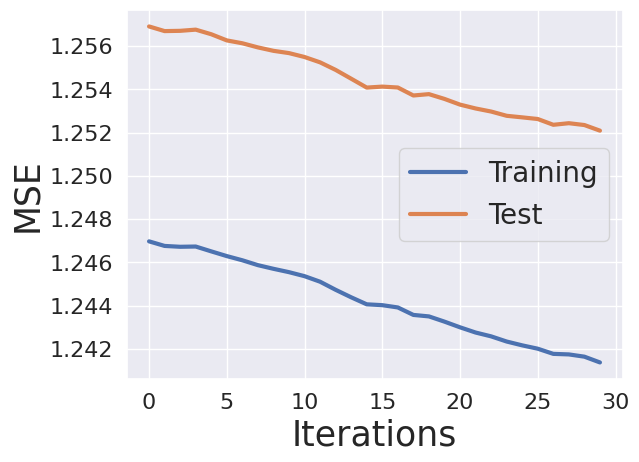

In [15]:
plot_learning_curve(MF_SGD)

In [16]:
del MF_SGD

### ALS without biases

In [17]:
MF_ALS = ExplicitMF(train, 40, optim="als", batch_size=64, n_batches=1_000, bias=False)
n_epochs = 30
MF_ALS.calculate_learning_curve(n_epochs, test, learning_rate=1e-3)

Training the model:   0%|          | 0/30 [00:00<?, ?it/s]

Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

...

Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

Epoch #30. MSE train: 5.3209, MSE test: 8.8221


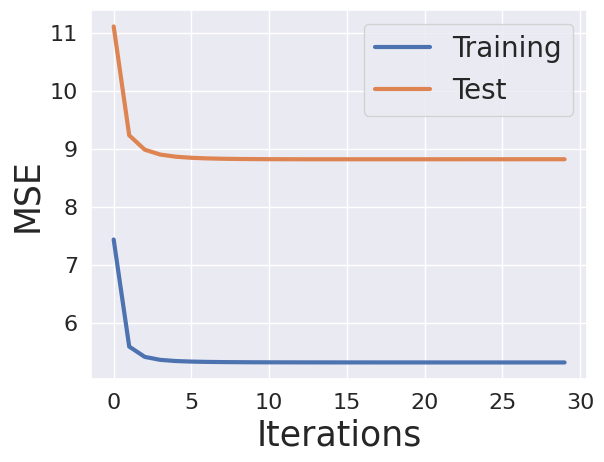

In [18]:
plot_learning_curve(MF_ALS)

In [19]:
del MF_ALS

## Experiments

In [20]:
import gc

gc.collect()

58904

In [21]:
import json

settings_dict = {
    "optim": ("sgd", "als"),
    "factor": (1, 10, 25, 50),
    "regularization": (
        0.0,
        0.001,
        0.01,
        0.1,
    ),  # It would have been better if I separated those
    # for weights and biases, but I do not think
    # that this would be feasable
}


results = dict()
n_epochs = 15
for optim in settings_dict["optim"]:
    results[optim] = dict()
    for factor in settings_dict["factor"]:
        results[optim][factor] = dict()
        for regularization in settings_dict["regularization"]:
            MF = ExplicitMF(
                train,
                factor,
                optim=optim,
                bias=False,
                item_fact_reg=regularization,
                user_fact_reg=regularization,
                item_bias_reg=regularization,
                user_bias_reg=regularization,
                batch_size=64,
                n_batches=1_000,
            )
            try:
                MF.calculate_learning_curve(n_epochs, test, learning_rate=1e-3)
                results[optim][factor][regularization] = [
                    MF.train_mse[-1],
                    MF.test_mse[-1],
                    MF.train_rmse[-1],
                    MF.test_rmse[-1],
                    MF.train_time,
                    MF.inference_time,
                ]
                del MF
            except:
                results[optim][factor][regularization] = [
                    np.nan
                ] * 6  # for the case when matrix is singular
                del MF

            MF = ExplicitMF(
                train,
                factor,
                optim=optim,
                bias=True,
                item_fact_reg=regularization,
                user_fact_reg=regularization,
                item_bias_reg=regularization,
                user_bias_reg=regularization,
                batch_size=64,
                n_batches=1_000,
            )
            try:
                MF.calculate_learning_curve(n_epochs, test, learning_rate=1e-3)
                results[optim][factor][regularization] += [
                    MF.train_mse[-1],
                    MF.test_mse[-1],
                    MF.train_rmse[-1],
                    MF.test_rmse[-1],
                    MF.train_time,
                    MF.inference_time,
                ]
                del MF
            except:
                results[optim][factor][regularization] += [
                    np.nan
                ] * 6  # for the case when matrix is singular
                del MF
            gc.collect()

Training the model:   0%|          | 0/15 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

Batched SGD:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch #10. MSE train: 49027120255699259721087053933003524739196570099362806715021561986554996703985554497337561021515169124131708796183646007939325859927667505102848.0000, MSE test: 23242090415355462415994135769843741421866846302293877066753597384185074516939516576042834520921070930557674082899131093622885832727477004271616.0000


Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

Updating user vectors:   0%|          | 0/6040 [00:00<?, ?it/s]

Updating item vectors:   0%|          | 0/3706 [00:00<?, ?it/s]

Let us see the results

In [32]:
results_mod = {
    (optim, factor, regularization): metrics
    for optim, fctr in results.items()
    for factor, regul in fctr.items()
    for regularization, metrics in regul.items()
}
results_df = pd.DataFrame(results_mod).T
results_df.columns = [
    "Train MSE (no biases)",
    "Test MSE (no biases)",
    "Train RMSE (no biases)",
    "Test RMSE (no biases)",
    "Train time (no biases), s",
    "Inference time (no biases), s",
    "Train MSE",
    "Test MSE",
    "Train RMSE",
    "Test RMSE",
    "Train time, s",
    "Inference time, s",
]
results_df

Train MSE (no biases)  Test MSE (no biases)  \
sgd 1  0.000              15.388284             16.306902   
       0.001              15.226151             16.202668   
       0.010              15.302029             16.274995   
       0.100              15.418080             16.371007   
    10 0.000              14.021560             14.914440   
       0.001              14.019100             14.915177   
       0.010              14.019612             14.911077   
       0.100              14.020072             14.912989   
    25 0.000              14.020785             14.911569   
       0.001              14.020092             14.911117   
       0.010              14.020579             14.911779   
       0.100              14.020408             14.911259   
    50 0.000              14.021147             14.911522   
       0.001              14.021112             14.911311   
       0.010              14.021190             14.911364   
       0.100              14.021119             14.911487   
als 1  0.000               8.660258             11.706327   
       0.001               8.660877             11.706767   
       0.010               8.662576             11.707976   
       0.100               8.683085             11.722544   
    10 0.000               6.511742              9.695622   
       0.001               6.511703              9.703156   
       0.010               6.511262              9.701404   
       0.100               6.514749              9.691781   
    25 0.000               5.729058              8.984630   
       0.001               5.729362              8.984117   
       0.010               5.734052              8.987464   
       0.100               5.732932              8.987408   
    50 0.000               5.117442              8.839749   
       0.001               5.115517              8.833419   
       0.010               5.116278              8.839562   
       0.100               5.117739              8.844980   

              Train RMSE (no biases)  Test RMSE (no biases)  \
sgd 1  0.000                3.922790               4.038181   
       0.001                3.902070               4.025254   
       0.010                3.911781               4.034228   
       0.100                3.926586               4.046110   
    10 0.000                3.744537               3.861922   
       0.001                3.744209               3.862017   
       0.010                3.744277               3.861486   
       0.100                3.744339               3.861734   
    25 0.000                3.744434               3.861550   
       0.001                3.744341               3.861492   
       0.010                3.744406               3.861577   
       0.100                3.744384               3.861510   
    50 0.000                3.744482               3.861544   
       0.001                3.744478               3.861517   
       0.010                3.744488               3.861524   
       0.100                3.744478               3.861539   
als 1  0.000                2.942832               3.421451   
       0.001                2.942937               3.421515   
       0.010                2.943225               3.421692   
       0.100                2.946707               3.423820   
    10 0.000                2.551812               3.113779   
       0.001                2.551804               3.114989   
       0.010                2.551718               3.114708   
       0.100                2.552401               3.113163   
    25 0.000                2.393545               2.997437   
       0.001                2.393609               2.997352   
       0.010                2.394588               2.997910   
       0.100                2.394354               2.997901   
    50 0.000                2.262176               2.973172   
       0.001                2.261751               2.972107   
       0.010                2.261919           

Here, instances when training could not be finished were marked with NaN. Several patterns occured according to this table:

- Intruduction of biases greatly increases model's performance (reduces MSE/RMSE by up to $86 \%$) if SGD optimizer is used;

    - Moreover, SGD's perfomance is impacted more by presence/absence of biases that ragularization terms and the number of factors.

- Introduction of biases for ALS does the opposite: the model reliably fails to converge during training. This might be the case because the training target is a matrix with all of its elements close to 0. This paired with imprecisions of floating-point operations and reliance on linear system solvers (i.e. matrix inversion) might lead to matrices' determinant exploding thus rendering the algorithm unable to converge properly.

- In case of SGD, increasing the amount of factors improves the model performance up to a certrain threshold. Introducing more than 10 does not give any boost to performance on the selected dataset (movielens-1M). The model reliably achieves thebest pefromance in terms of MSE and RMSE when all regulariazation terms are set to 0.001.

- In case of ALS, increasing the amount of factors seems to increase models performance and model shows the best performance when there is no regularization.

- In both cases model inference time doubles with introduction of biases, yet training time sees an increase of ~0.4s.

- Notably, while SGD training time marginally increases with the number of factors, ALS sees a dramatic increase in train time with increase in number of factors. This is the case since each training step in ALS contains a matrix multplication of two matrices of shape (n, f), where n is the number of users/items and f is the number of factors. This takes at most $\cal{O}(f \times n \times n)$ operations. Thus, increase in f with stationary n results in linear increase in operation time.

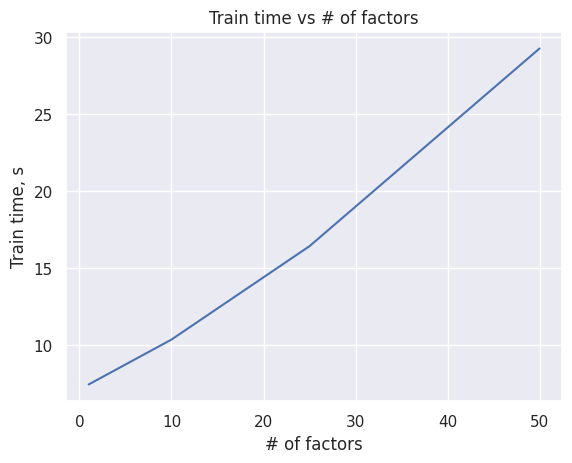

In [48]:
tt = results_df["Train time (no biases), s"]["als"].iloc[::4]
plt.plot([1, 10, 25, 50], tt)
plt.title("Train time vs # of factors")
plt.xlabel("# of factors")
plt.ylabel("Train time, s")
plt.show()